# The Generation process of novel SMAs and QMs

## Import related packages

In [52]:
from rdkit.Chem import BRICS
from rdkit import Chem
import os
from pandas import DataFrame
import numpy as np
import itertools
import pandas as pd
from rdkit import rdBase, Chem
from rdkit.Chem import AllChem, Draw, BRICS, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import RDConfig
from rdkit.Chem import AllChem, Draw, BRICS, Descriptors

## Obtain core substructures

In [53]:
smiles = 'O=C(C1=C(C/2=C(C#N)/C#N)C=C(C(F)=C1)F)C2=C/C(SC3=C4N(C5=C3C6=NN(N=C6C7=C5N(C8=C7SC(/C=C9C(C%10=C(C\9=C(C#N)\C#N)C=C(C(F)=C%10)F)=O)=C8CCOCC(CCCCCC)CCCC)CC(CCCC)CC)CC(CCCC)CC)CC(CCCC)CC)=C4CCOCC(CCCC)CCCCCC'

In [54]:
mol = Chem.MolFromSmiles(smiles) 

In [55]:
fragment = BRICS.BRICSDecompose(mol,  minFragmentSize=6, silent=True, keepNonLeafNodes=True, singlePass=False, returnMols=False)

In [56]:
frag_1dummy_s = [smiles for smiles in fragment if smiles.count('*')==2]
frag_1dummy_s = [smiles for smiles in frag_1dummy_s if  smiles.count('7*')==2]
smiles =  frag_1dummy_s[0].replace('C[7*]','[7*]').replace('[7*]C','[7*]')

In [57]:
frag_1dummy = np.array([Chem.MolFromSmiles(smiles)])
img1 = Draw.MolToImage(frag_1dummy1[0],size=(500,500))

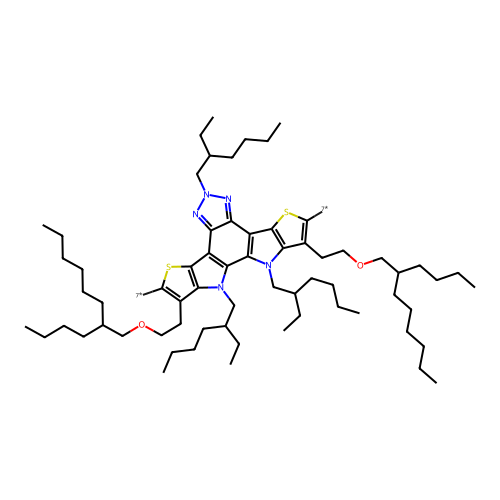

In [58]:
img1

## Obtain Terminal units

In [59]:
          
frag_2dummy_s = ['O=C(c1c(C/2=C(C#N)/C#N)cccc1)C2=C/[7*]',
            'O=C(c1c(C/2=C(C#N)/C#N)cc(Cl)c(Cl)c1)C2=C/[7*]',
            'O=C(c1c(C/2=C(C#N)/C#N)cc(F)c(F)c1)C2=C/[7*]',
            'O=C(c1c(C/2=C(C#N)/C#N)ccc(F)c1)C2=C/[7*]',
            'O=C(c1c(C/2=C(C#N)/C#N)ccc(Cl)c1)C2=C/[7*]']

frag_3dummy_s =            [  
            'O=C(c1c(C/2=C(C#N)\C#N)ccc(Br)c1)C2=C/[7*]']

In [60]:
frag_2dummy = np.array([Chem.MolFromSmiles(smiles) for smiles in frag_2dummy_s])
frag_3dummy = np.array([Chem.MolFromSmiles(smiles) for smiles in frag_3dummy_s])

### Define generation function

In [61]:

def structure_generator(main_mol, fragment1, fragment2, r_position=1):
 
    """
    parameters
    ----------
    main_mol : RDkit Mol object
    fragment1 : RDkit Mol object
    fragment2 : RDkit Mol object
    r_position : int (1 or 2) 
        fragment1
    Returns
    ----------
    generated_molecule : RDkit Mol object
    """
    bond_list = [Chem.rdchem.BondType.UNSPECIFIED, Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
             Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.QUADRUPLE, Chem.rdchem.BondType.QUINTUPLE,
             Chem.rdchem.BondType.HEXTUPLE, Chem.rdchem.BondType.ONEANDAHALF, Chem.rdchem.BondType.TWOANDAHALF,
             Chem.rdchem.BondType.THREEANDAHALF, Chem.rdchem.BondType.FOURANDAHALF, Chem.rdchem.BondType.FIVEANDAHALF,
             Chem.rdchem.BondType.AROMATIC, Chem.rdchem.BondType.IONIC, Chem.rdchem.BondType.HYDROGEN,
             Chem.rdchem.BondType.THREECENTER, Chem.rdchem.BondType.DATIVEONE, Chem.rdchem.BondType.DATIVE,
             Chem.rdchem.BondType.DATIVEL, Chem.rdchem.BondType.DATIVER, Chem.rdchem.BondType.OTHER,
             Chem.rdchem.BondType.ZERO]
 
    # make adjacency matrix and get atoms for main molecule
    level1_adjacency_matrix = Chem.rdmolops.GetAdjacencyMatrix(fragment1)
 
    for bond in fragment1.GetBonds():
        level1_adjacency_matrix[bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()] = bond_list.index(bond.GetBondType())
        level1_adjacency_matrix[bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()] = bond_list.index(bond.GetBondType())
    level1_atoms = []
    for atom in fragment1.GetAtoms():
        level1_atoms.append(atom.GetSymbol())
 
    r_index_in_level1_molecule_old = [index for index, atom in enumerate(level1_atoms) if atom == '*']
 
    for index, r_index in enumerate(r_index_in_level1_molecule_old):
        modified_index = r_index - index
        atom = level1_atoms.pop(modified_index)
        level1_atoms.append(atom)
        tmp = level1_adjacency_matrix[:, modified_index:modified_index + 1].copy()
        level1_adjacency_matrix = np.delete(level1_adjacency_matrix, modified_index, 1)
        level1_adjacency_matrix = np.c_[level1_adjacency_matrix, tmp]
        tmp = level1_adjacency_matrix[modified_index:modified_index + 1, :].copy()
        level1_adjacency_matrix = np.delete(level1_adjacency_matrix, modified_index, 0)
        level1_adjacency_matrix = np.r_[level1_adjacency_matrix, tmp]
 
    r_index_in_level1_molecule_new = [index for index, atom in enumerate(level1_atoms) if atom == '*']
 
    r_bonded_atom_index_in_level1_molecule = []
    for number in r_index_in_level1_molecule_new:
        r_bonded_atom_index_in_level1_molecule.append(np.where(level1_adjacency_matrix[number, :] != 0)[0][0])
 
    r_bond_number_in_level1_molecule = level1_adjacency_matrix[
        r_index_in_level1_molecule_new, r_bonded_atom_index_in_level1_molecule]
 
    level1_adjacency_matrix = np.delete(level1_adjacency_matrix, r_index_in_level1_molecule_new, 0)
    level1_adjacency_matrix = np.delete(level1_adjacency_matrix, r_index_in_level1_molecule_new, 1)
 
    for i in range(len(r_index_in_level1_molecule_new)):
        level1_atoms.remove('*')
    level1_size = level1_adjacency_matrix.shape[0]
 
    generated_molecule_atoms = level1_atoms[:]
    generated_adjacency_matrix = level1_adjacency_matrix.copy()
 
    frag_permutations = list(itertools.permutations([main_mol, fragment2]))
    fragment_list = frag_permutations[r_position]
 
    for r_number_in_molecule, fragment_molecule in enumerate(fragment_list):  
 
        fragment_adjacency_matrix = Chem.rdmolops.GetAdjacencyMatrix(fragment_molecule)
 
        for bond in fragment_molecule.GetBonds():
            fragment_adjacency_matrix[bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()] = bond_list.index(
                bond.GetBondType())
            fragment_adjacency_matrix[bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()] = bond_list.index(
                bond.GetBondType())
        fragment_atoms = []
        for atom in fragment_molecule.GetAtoms():
            fragment_atoms.append(atom.GetSymbol())
 
        r_index_in_fragment_molecule = fragment_atoms.index('*')
 
        r_bonded_atom_index_in_fragment_molecule = \
            np.where(fragment_adjacency_matrix[r_index_in_fragment_molecule, :] != 0)[0][0]
 
        if r_bonded_atom_index_in_fragment_molecule > r_index_in_fragment_molecule:
            r_bonded_atom_index_in_fragment_molecule -= 1
 
        fragment_atoms.remove('*')
        fragment_adjacency_matrix = np.delete(fragment_adjacency_matrix, r_index_in_fragment_molecule, 0)
        fragment_adjacency_matrix = np.delete(fragment_adjacency_matrix, r_index_in_fragment_molecule, 1)
 
        main_size = generated_adjacency_matrix.shape[0]
        generated_adjacency_matrix = np.c_[generated_adjacency_matrix, np.zeros(
            [generated_adjacency_matrix.shape[0], fragment_adjacency_matrix.shape[0]], dtype='int32')]
        generated_adjacency_matrix = np.r_[generated_adjacency_matrix, np.zeros(
            [fragment_adjacency_matrix.shape[0], generated_adjacency_matrix.shape[1]], dtype='int32')]
 
        generated_adjacency_matrix[r_bonded_atom_index_in_level1_molecule[r_number_in_molecule], 
                                   r_bonded_atom_index_in_fragment_molecule + main_size] = \
            r_bond_number_in_level1_molecule[r_number_in_molecule]
 
        generated_adjacency_matrix[r_bonded_atom_index_in_fragment_molecule + main_size, 
                                   r_bonded_atom_index_in_level1_molecule[r_number_in_molecule]] = \
            r_bond_number_in_level1_molecule[r_number_in_molecule]
 
        generated_adjacency_matrix[main_size:, main_size:] = fragment_adjacency_matrix
 
        # integrate atoms
        generated_molecule_atoms += fragment_atoms
 
    # generate structures 
    generated_molecule = Chem.RWMol()
    atom_index = []
 
    for atom_number in range(len(generated_molecule_atoms)):
        atom = Chem.Atom(generated_molecule_atoms[atom_number])
        molecular_index = generated_molecule.AddAtom(atom)
        atom_index.append(molecular_index)
 
    for index_x, row_vector in enumerate(generated_adjacency_matrix):    
        for index_y, bond in enumerate(row_vector):      
            if index_y <= index_x:
                continue
            if bond == 0:
                continue
            else:
                generated_molecule.AddBond(atom_index[index_x], atom_index[index_y], bond_list[bond])
 
    generated_molecule = generated_molecule.GetMol()
 
    return generated_molecule


##  Generate SMAs

In [62]:
smiles= []          
for i in range (len(frag_1dummy)) :
    fragment1 = frag_1dummy[i]
    for j in range(len (frag_2dummy)):
        fragment2 = frag_2dummy[j]  
        mol = structure_generator(fragment2,fragment1,fragment2 )  
        smi  = Chem.MolToSmiles(mol)
        smiles.append(smi )

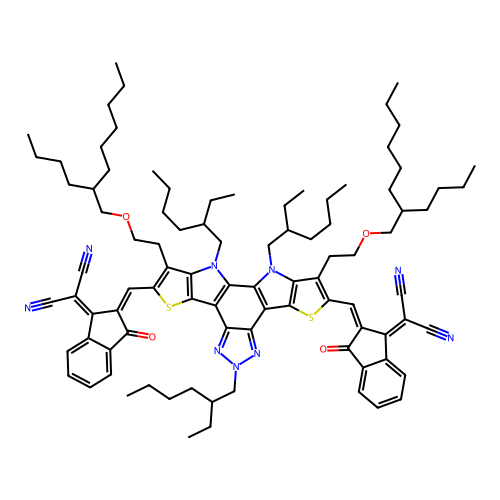

In [63]:
img2 = Draw.MolToImage(Chem.MolFromSmiles(smiles[0]),size=(500,500))
img2

# Generate QMs

In [64]:
smiles= []          
for i in range (len(frag_1dummy)) :
    fragment1 = frag_1dummy[i]
    for j in range(len (frag_2dummy)):
        fragment2 = frag_2dummy[j]
       
        mol = structure_generator(frag_3dummy[0],fragment1,fragment2 )  
        smile = Chem.MolToSmiles(mol)
        smile =  smile.replace('Br','[16*]')
        frag_4dummy = np.array([Chem.MolFromSmiles(smile) ])
        mol = structure_generator(frag_4dummy[0],Chem.MolFromSmiles('[14*]c1ccc([14*])s1'),frag_4dummy[0] )
        
        smi  = Chem.MolToSmiles(mol)
        
        smiles.append(smi )

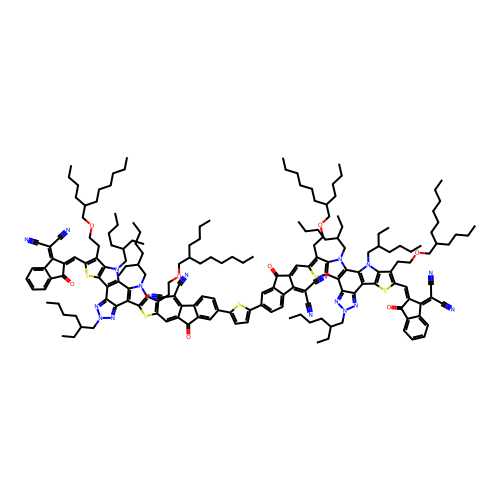

In [65]:
img3 = Draw.MolToImage(Chem.MolFromSmiles(smiles[0]),size=(500,500))
img3